In [1]:
from tdc.single_pred import Tox
from rdkit import Chem, RDLogger
from rdkit.Chem import Lipinski, Descriptors, Crippen,rdMolDescriptors, GraphDescriptors, QED
from rdkit.Chem import Fragments, AllChem
from rdkit.Chem.rdMolDescriptors import (
    CalcTPSA, CalcKappa1, CalcKappa2, CalcKappa3,
    CalcChi0v, CalcChi1v, CalcChi2v, CalcChi3v, CalcChi4v,
    CalcChi0n, CalcChi1n, CalcChi2n, CalcChi3n, CalcChi4n,
)

RDLogger.DisableLog('rdApp.*')

from copy import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Local utilities
import sys
sys.path.insert(0, '.')

random_state = 0

In [4]:
df = pd.read_csv('../data/processed/toxicity_dataset_with_descriptors.csv')

## Exploratory Data Analysis (EDA)

In [5]:
# Basic dataset info
print(f"Dataset Shape: {df.shape}")
print(f"\nMissing Values: {df.isnull().sum().sum()} total")
print("\nTarget Column (LD50) Stats:")
print(df['Y'].describe())

Dataset Shape: (5170, 14)

Missing Values: 0 total

Target Column (LD50) Stats:
count    5170.000000
mean        2.537543
std         0.959473
min        -0.343000
25%         1.854000
50%         2.366000
75%         3.023000
max        10.207000
Name: Y, dtype: float64


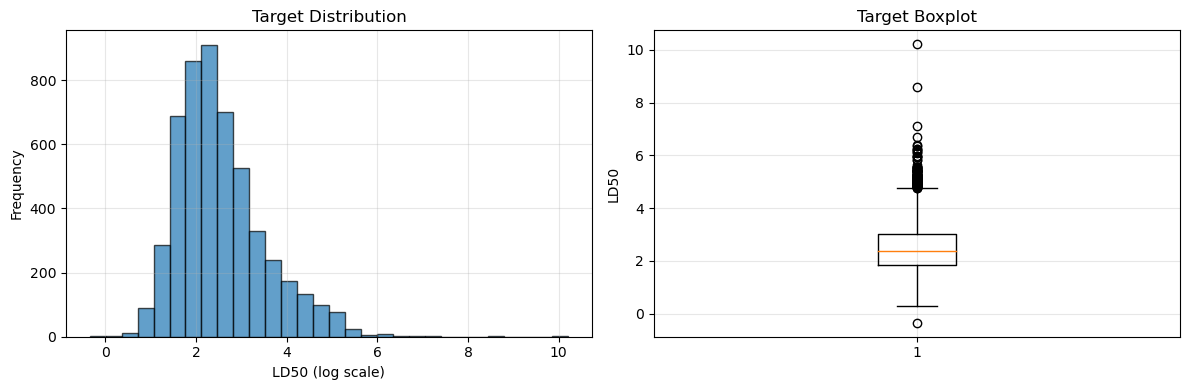

In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Y'], bins=30, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('LD50 (log scale)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Target Distribution')
axes[0].grid(alpha=0.3)

axes[1].boxplot(df['Y'], vert=True)
axes[1].set_ylabel('LD50')
axes[1].set_title('Target Boxplot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Feature Relevance (Spearman correlation with target):
                         corr           pval  abs_corr
HeavyAtomMolWt       0.389118  1.609590e-186  0.389118
MolWt                0.377649  6.161468e-175  0.377649
ExactMolWt           0.376874  3.589247e-174  0.376874
NumValenceElectrons  0.297311  5.168995e-106  0.297311
MaxPartialCharge     0.227378   1.299188e-61  0.227378
MinAbsPartialCharge  0.193054   1.358986e-44  0.193054
FpDensityMorgan3     0.093805   1.397909e-11  0.093805
MinPartialCharge     0.047828   5.815263e-04  0.047828
FpDensityMorgan2     0.029872   3.172886e-02  0.029872
MaxAbsPartialCharge  0.021216   1.271892e-01  0.021216
FpDensityMorgan1     0.007083   6.106175e-01  0.007083


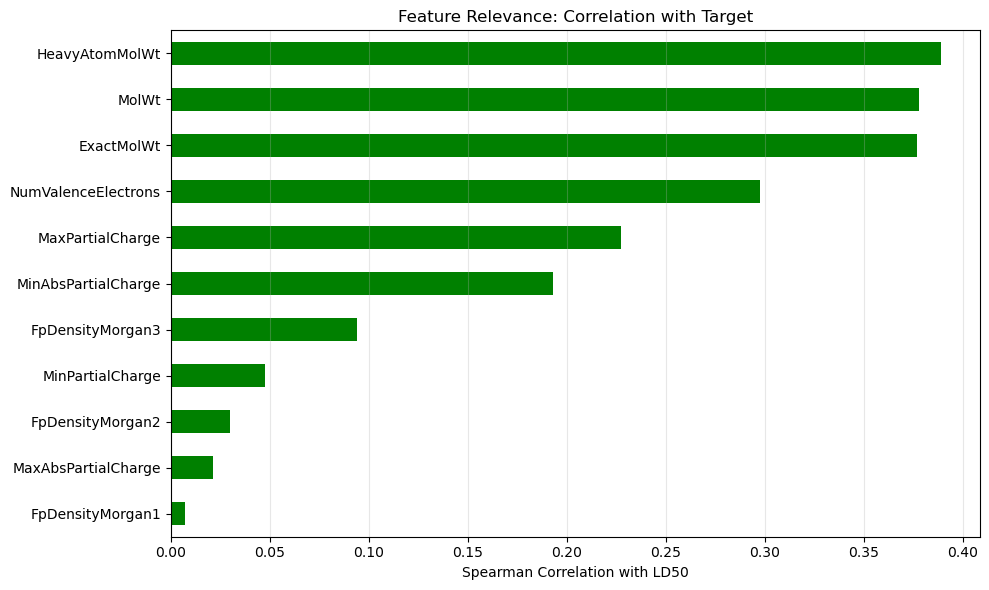

In [7]:
# Feature relevance: Spearman correlations with target
descriptor_cols = df.columns.difference(['Drug_ID', 'Y', 'canonical_smiles'])
correlations = {}

for col in descriptor_cols:
    valid_mask = (df[col].notna()) & (df['Y'].notna())
    if valid_mask.sum() > 0:
        corr, pval = spearmanr(df[col][valid_mask], df['Y'][valid_mask])
        correlations[col] = {'corr': corr, 'pval': pval, 'abs_corr': abs(corr)}

corr_df = pd.DataFrame(correlations).T.sort_values('abs_corr', ascending=False)
print("Feature Relevance (Spearman correlation with target):")
print(corr_df)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
corr_df['corr'].sort_values().plot(kind='barh', ax=ax, color=['red' if x < 0 else 'green' for x in corr_df['corr'].sort_values()])
ax.set_xlabel('Spearman Correlation with LD50')
ax.set_title('Feature Relevance: Correlation with Target')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

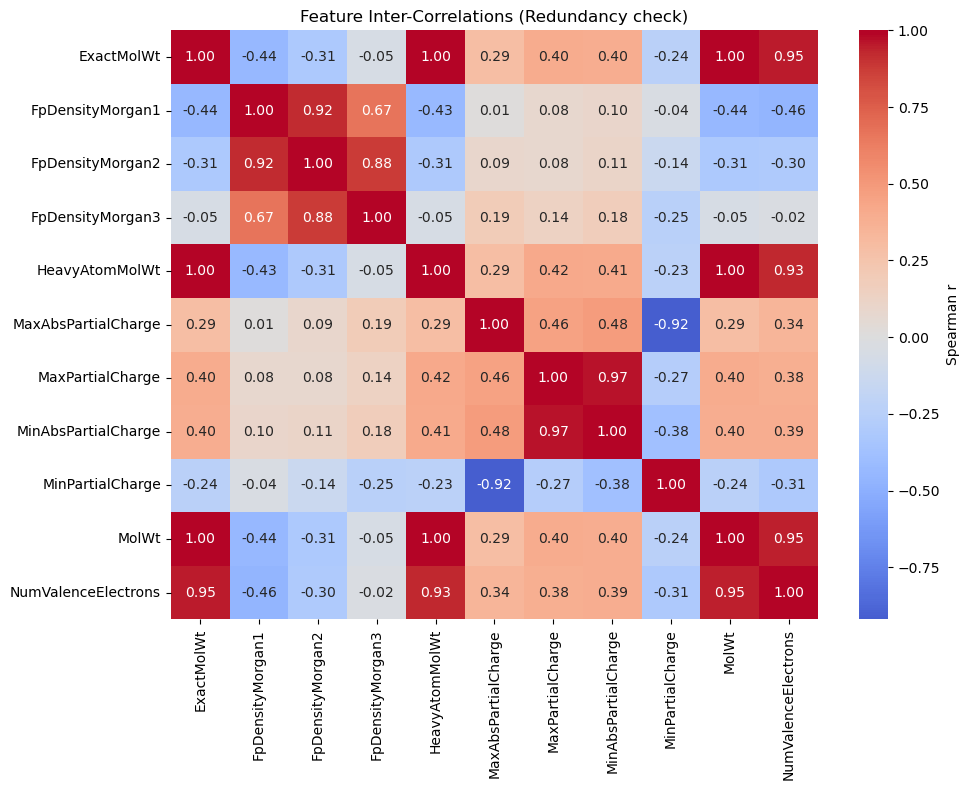


Highly Correlated Feature Pairs (|r| > 0.7):
  ExactMolWt <-> HeavyAtomMolWt: 0.998
  ExactMolWt <-> MolWt: 1.000
  ExactMolWt <-> NumValenceElectrons: 0.949
  FpDensityMorgan1 <-> FpDensityMorgan2: 0.918
  FpDensityMorgan2 <-> FpDensityMorgan3: 0.880
  HeavyAtomMolWt <-> MolWt: 0.998
  HeavyAtomMolWt <-> NumValenceElectrons: 0.932
  MaxAbsPartialCharge <-> MinPartialCharge: -0.919
  MaxPartialCharge <-> MinAbsPartialCharge: 0.966
  MolWt <-> NumValenceElectrons: 0.947


In [8]:
# Inter-feature redundancy check
df_desc = df[descriptor_cols]
corr_matrix = df_desc.corr(method='spearman')

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Spearman r'})
ax.set_title('Feature Inter-Correlations (Redundancy check)')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (redundancy)
print("\nHighly Correlated Feature Pairs (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"  {corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

Linear Regression Coefficients (model importance):
                Feature  Coefficient  Abs_Coef
6      MaxPartialCharge     7.770701  7.770701
7   MinAbsPartialCharge    -7.519910  7.519910
5   MaxAbsPartialCharge    -4.454568  4.454568
8      MinPartialCharge    -3.423225  3.423225
1      FpDensityMorgan1     0.819103  0.819103
2      FpDensityMorgan2    -0.649783  0.649783
3      FpDensityMorgan3     0.438578  0.438578
9                 MolWt    -0.091514  0.091514
0            ExactMolWt     0.088178  0.088178
4        HeavyAtomMolWt     0.009700  0.009700
10  NumValenceElectrons    -0.007351  0.007351

Model R² Score: 0.2100


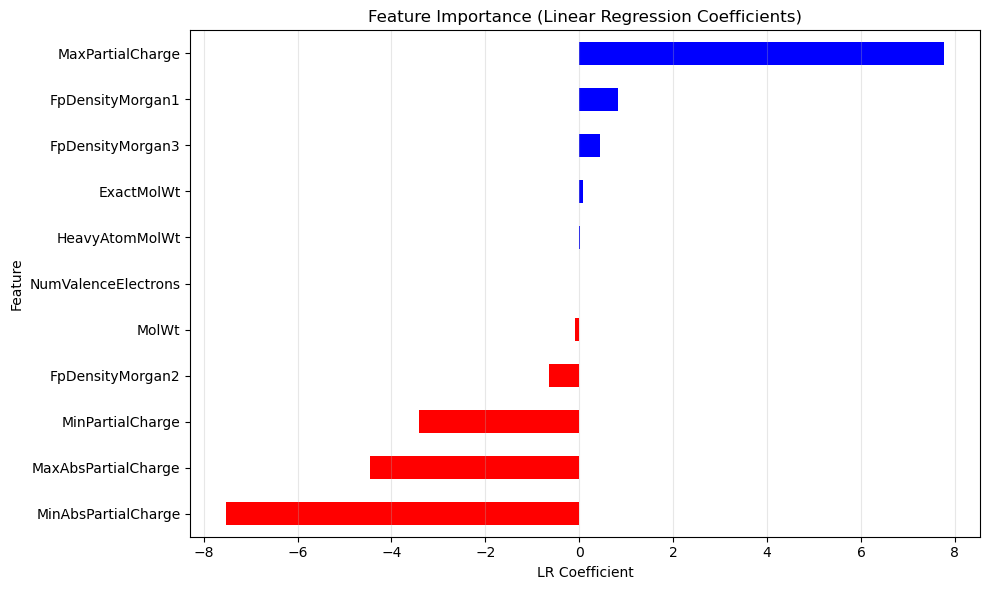

In [ ]:
# Feature importance via Linear Regression
X = df[descriptor_cols].fillna(df[descriptor_cols].mean())
y = df['Y']

# Fit a simple linear model
lr = LinearRegression()
lr.fit(X, y)

# Get coefficients
coef_df = pd.DataFrame({
    'Feature': descriptor_cols,
    'Coefficient': lr.coef_,
    'Abs_Coef': np.abs(lr.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("Linear Regression Coefficients (model importance):")
print(coef_df)
print(f"\nModel R² Score: {lr.score(X, y):.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
coef_df.set_index('Feature')['Coefficient'].sort_values().plot(kind='barh', ax=ax, 
                                                                color=['red' if x < 0 else 'blue' for x in coef_df.set_index('Feature')['Coefficient'].sort_values()])
ax.set_xlabel('LR Coefficient')
ax.set_title('Feature Importance (Linear Regression Coefficients)')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

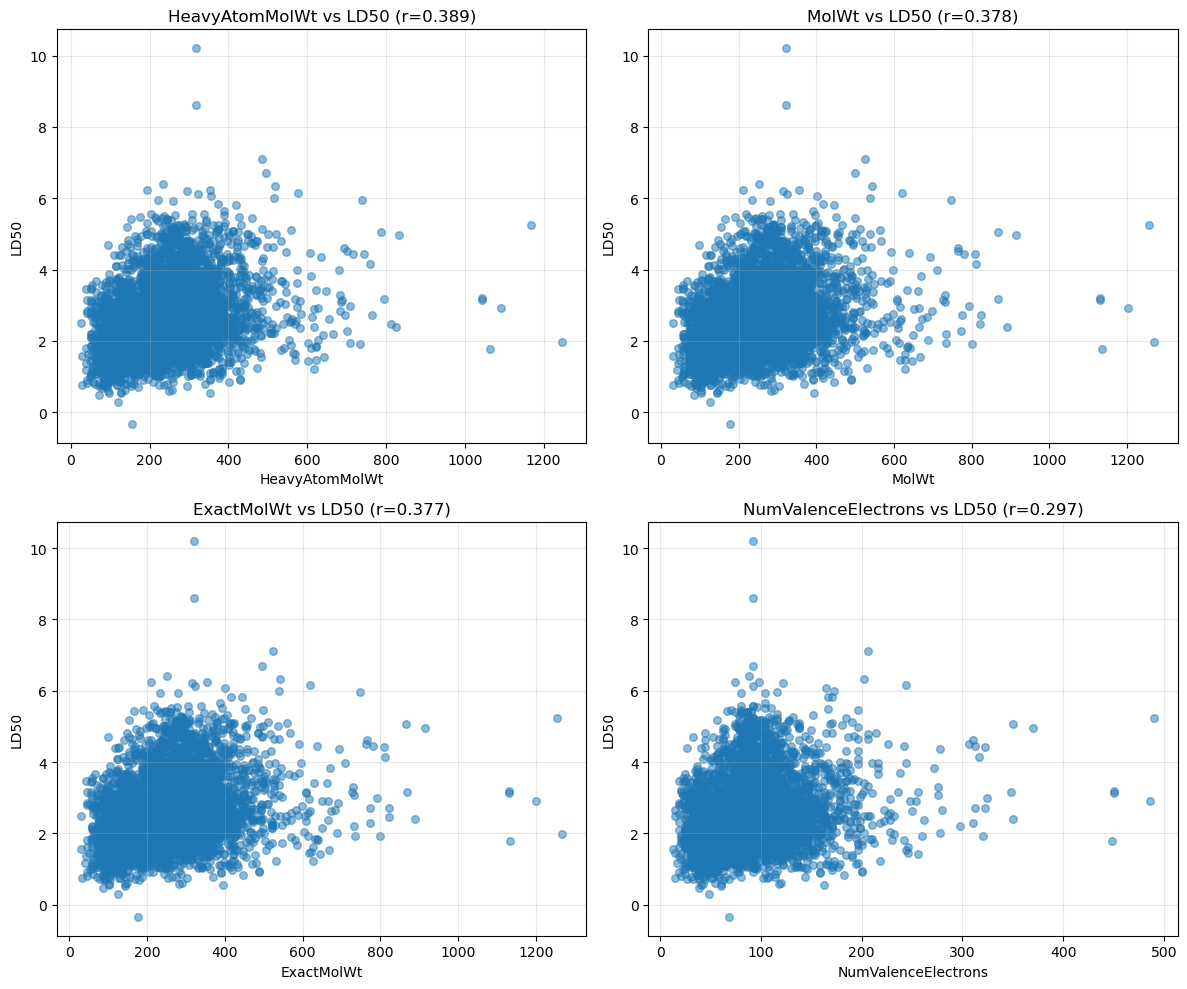

In [10]:
# Scatter plots: Top features vs target
top_features = corr_df.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    valid_mask = (df[feat].notna()) & (df['Y'].notna())
    axes[idx].scatter(df[feat][valid_mask], df['Y'][valid_mask], alpha=0.5, s=30)
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('LD50')
    corr_val = corr_df.loc[feat, 'corr']
    axes[idx].set_title(f'{feat} vs LD50 (r={corr_val:.3f})')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()